# Capítulo 5: Variáveis aleatórias multidimensionais

<hr>

Códigos do livro: **Probabilidade e Estatística: Teoria, simulação e Dadados**<br>
Site: https://loja.uiclap.com/titulo/ua158988 <br>
Autor: Francisco A. Rodrigues<br>
https://sites.icmc.usp.br/francisco<br>
Universidade de São Paulo<br>
<hr>

In [1]:
# Pág. 174
import numpy as np
np.random.seed(10)
p = 2/3 # probabilidade de jogar no ataque
lbd0 = 1 # taxa de gols no meio do campo
lbd1 = 2 # taxa de gols no ataque
ns = 1000 # número de simulações
goals = 0 # número de gols
for s in range(0,ns):
    if (np.random.uniform() < p):
        # jogador joga no ataque
        goals = goals + np.random.poisson(lbd1)
    else:
        # jogador joga no meio do campo
        goals = goals + np.random.poisson(lbd0)
print("E[X] = ", goals/ns)

E[X] =  1.632


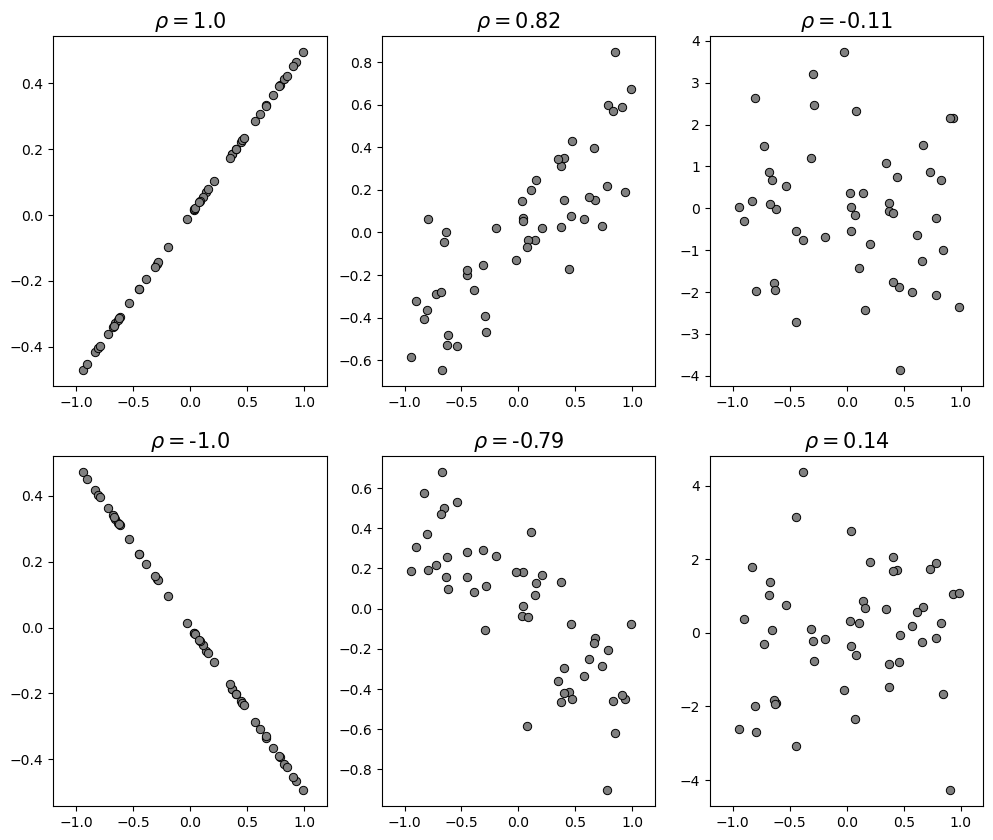

In [2]:
# Pág. 177
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

np.random.seed(101)
N = 50 # número de observações
X = np.random.uniform(-1,1,N)
# valores das variâncias
sigma = [0,0.2,1.5,0,0.2,1.5]
# coeficente de inclinação
a = [0.5,0.5,0.5,-0.5,-0.5,-0.5]
plt.figure(figsize=(12,10))
for i in range(0,len(a)):
    # gera os dados
    Y = a[i]*X + np.random.normal(0,sigma[i],N)
    # mostra os gráficos
    plt.subplot(2,3,i+1)
    plt.plot(X,Y, color = 'gray', 
             marker='o', linestyle='None', 
             markeredgewidth = 0.7,
             markeredgecolor = 'black')
    plt.xlim(-1.2,1.2)
    # calcula o coeficiente de correlação de Pearson
    corr, p_value = pearsonr(X, Y) 
    # mostra apenas duas casas decimais
    corr = round(corr*100)/100 
    plt.title(r'$\rho=$'+ str(corr), fontsize=15)
plt.show(True)

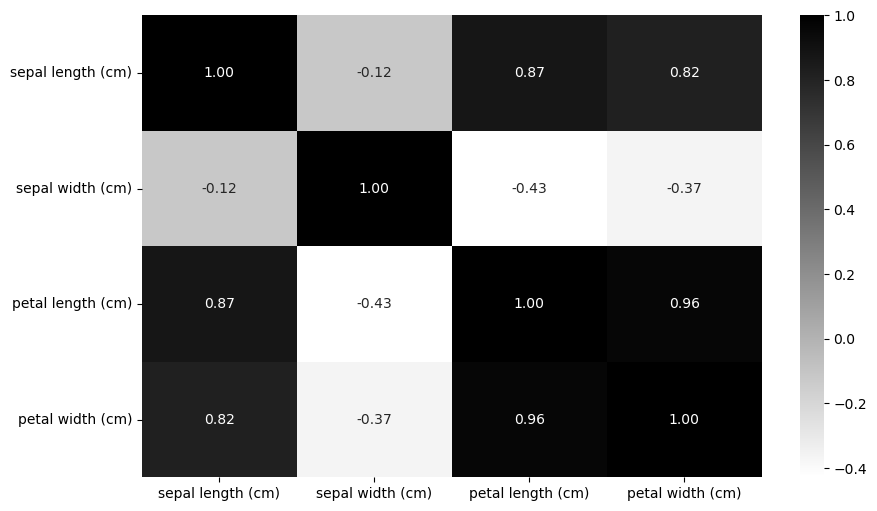

In [3]:
# Pág. 179
import pandas as pd
from sklearn import datasets
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
# carrega os dados
iris = datasets.load_iris()
# transforma em um dataframe do Pandas
data = pd.DataFrame(data=iris.data, 
                  columns=iris.feature_names)
# calcula as correlações entre as variáveis
matrix_corr = data.corr()
# mostra a matriz de correlação
hm = sns.heatmap(matrix_corr, annot = True, 
                 cmap='gist_gray_r', fmt='.2f')
plt.show()

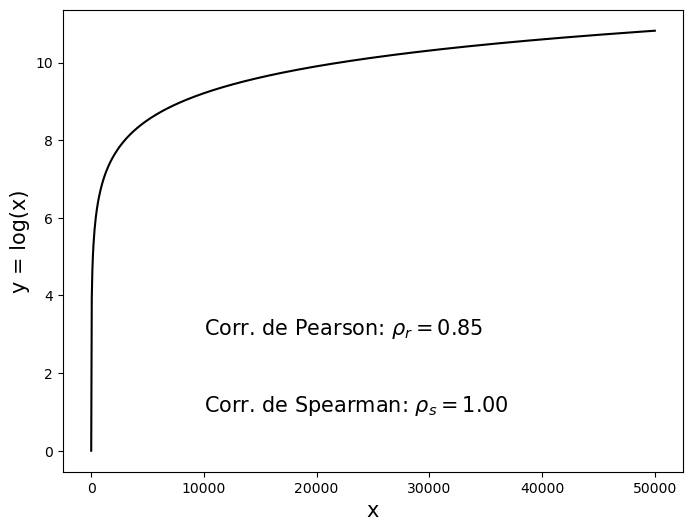

In [4]:
# Pág. 181
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

N = 1000 # tamanho da amostra
x = np.linspace(1, 50000, N) 
y = np.log(x)
# mostra os dados
plt.figure(figsize=(8,6))
plt.plot(x, y, 'k-') 
plt.xlabel("x", fontsize = 15) 
plt.ylabel("y = log(x)", fontsize = 15) 
corr, p_value = pearsonr(x, y) # correlação de Pearson
corrs, p_values = spearmanr(x, y) # correlação de Spearman
sp = r'Corr. de Pearson: $\rho_r = {:.2f}$'.format(corr)
plt.text(10000,3, sp, fontsize=15)
ss = r'Corr. de Spearman: $\rho_s = {:.2f}$'.format(corrs)
plt.text(10000,1, ss, fontsize=15)
plt.show()

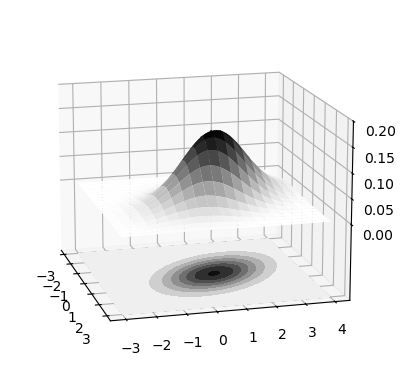

In [5]:
# Pág. 183
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import multivariate_normal

N = 60 # número de pontos gerados
X = np.linspace(-3, 3, N)
Y = np.linspace(-3, 4, N)
X, Y = np.meshgrid(X, Y)

# vetor média
mu = np.array([0., 1.]) 
# matriz de covariância
Sigma = np.array([[ 1.0 , -0.5], [-0.5,  1.5]])

# Empilha X e Y na última dimensão: (N, N, 2)
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y

F = multivariate_normal(mu, Sigma)
Z = F.pdf(pos)
# cria uma superfície e projeta o contorno
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
ax.plot_surface(X, Y, Z, rstride=3, cstride=3, 
                linewidth=1, antialiased=True,
                cmap=cm.gist_yarg)

cset = ax.contourf(X, Y, Z, zdir='z', offset=-0.15, 
                   cmap=cm.gist_yarg)

# ajusta os limites e o ângulo de visão
ax.set_zlim(-0.15,0.2)
ax.set_zticks(np.linspace(0,0.2,5))
ax.view_init(15, -15)
plt.show()

Pearson correlation: -0.8125410298226907
Pearson correlation: -0.012535250272788713
Pearson correlation: 0.8278622278253678


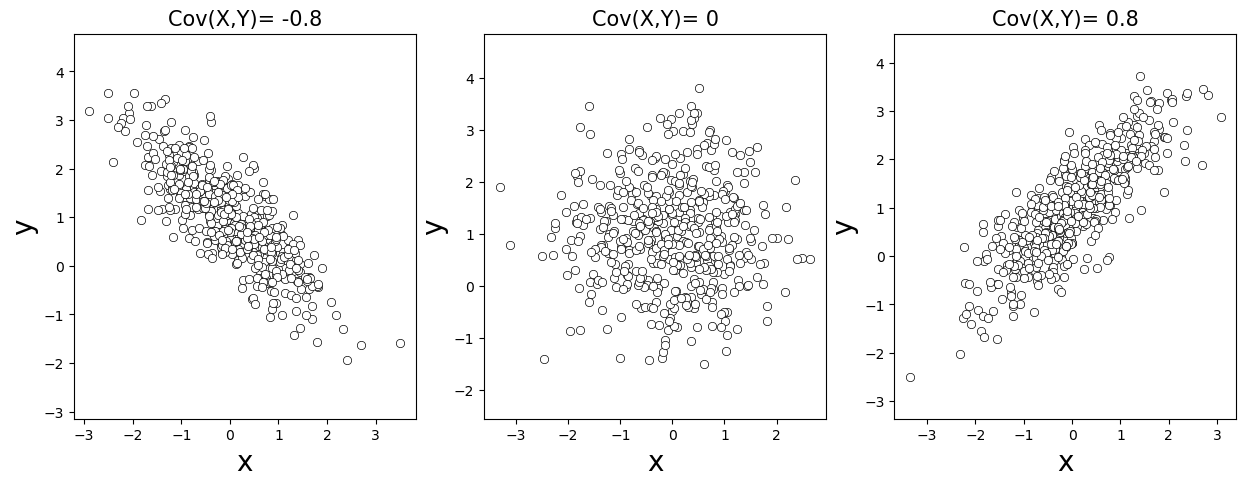

In [6]:
# Pág. 185
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from scipy.stats import pearsonr

np.random.seed(10)

# vetor média
mu = np.array([0., 1.]) 
# matriz de covariância
Sigma = np.array([[ 1.0, -0.5], [-0.5,  1]])
cov_val = [-0.8, 0, 0.8]

plt.figure(figsize=(15,5))
for idx, val in enumerate(cov_val):
    plt.subplot(1,3,idx+1)
    Sigma = np.array([[1, val], [val, 1]])
    F = multivariate_normal(mu, Sigma)
    data = F.rvs(size = 500)
    
    plt.plot(data[:,0],data[:,1], color = 'white', 
             marker='o', linestyle='None', 
             markeredgewidth = 0.5,
             markeredgecolor = 'black')
    plt.xlabel('x',fontsize = 20)
    plt.ylabel('y',fontsize = 20)
    plt.title(f'Cov(X,Y)= {val}', fontsize=15)
    plt.axis('equal')
    corr, p_value = pearsonr(data[:,0],data[:,1]) 
    print('Pearson correlation:', corr)
plt.show()

In [7]:
# Pág. 192
import pandas as pd
from sklearn import datasets
from scipy.stats import spearmanr, pearsonr

# carrega os dados
iris = datasets.load_iris()
# transforma em um dataframe do Pandas
df = pd.DataFrame(data=iris.data, 
                  columns=iris.feature_names)
# comprimento da pétala ('petal length')
X = df[iris.feature_names[2]] 
# largura da pétala ('petal width')
Y = df[iris.feature_names[3]] 
corrp, p_value_p = pearsonr(X, Y) # correlação de Pearson
print('Correlação de Pearson:', corrp)
corrs, p_value_s = spearmanr(X, Y) # correlação de Spearman
print('Correlação de Spearman:', corrs)

Correlação de Pearson: 0.962865431402796
Correlação de Spearman: 0.9376668235763412
